In [ ]:
!pip install atlasopenmagic
!pip install pyarrow==20.0.0

from atlasopenmagic import install_from_environment
install_from_environment(environment_file="../backend/environment.yml")

  Using cached atlasopenmagic-1.8.0-py3-none-any.whl.metadata (5.8 kB)
Using cached atlasopenmagic-1.8.0-py3-none-any.whl (21 kB)
  Using cached pyarrow-20.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.3 kB)
Using cached pyarrow-20.0.0-cp312-cp312-manylinux_2_28_x86_64.whl (42.3 MB)
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 15.0.2
    Uninstalling pyarrow-15.0.2:
      Successfully uninstalled pyarrow-15.0.2
Installing packages: ['aiohttp>=3.9.5', 'atlasopenmagic>=1.2.0', 'awkward>=2.8.5', 'awkward-pandas>=2023.8.0', 'fsspec>=2025.7.0', 'hist>=2.8.0', 'ipykernel>=6.29.5', 'jupyter>=1.0.0', 'lmfit>=1.3.2', 'matplotlib>=3.9.1', 'metakernel>=0.30.2', 'notebook>=7', 'numpy>=1.26.4', 'pandas>=2.2.2', 'papermill>=2.6.0', 'pip>=24.2', 'scikit-learn>=1.5.1', 'uproot>=5.3.10', 'uproot3>=3.14.4', 'fsspec-xrootd>=0.5.1', 'jupyterlab_latex>=3.1.0', 'vector>=1.4.1']
  Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata

In [ ]:
import os
import re
import awkward as ak
import time
import datetime
from zoneinfo import ZoneInfo
import uproot
import glob
import numpy as np
import vector
import hist
from hist import Hist
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator 
from lmfit import fit_report
from lmfit.models import PolynomialModel, GaussianModel,ExpressionModel
import pyarrow.parquet as pq
import sys
sys.path.append('../')
from backend import get_valid_variables, validate_read_variables
from backend import plot_stacked_hist, plot_histograms, histogram_2d, plot_errorbars
from backend import get_histogram, analysis_parquet, VALID_STR_CODE, produced_event_count

In [2]:
import vector
from analysis_tools import analysis_parquet, get_valid_variables  # assuming these exist

# ------------------------
# 1️⃣ Datasets and variables
# ------------------------
string_code_list = ['GamGam', 'Hyy']  # List of datasets to process
read_variables = get_valid_variables('GamGam')  # Load all valid variables for 'GamGam'

# ------------------------
# 2️⃣ Output directory for Parquet files
# ------------------------
output_dir = '../../output-parquet/tightiso'

# ------------------------
# 3️⃣ Custom preselection function
# ------------------------
def preselection_cut(data):
    """
    Apply di-photon preselection cuts:
    - Exactly 2 photons
    - Photon pT > 30 GeV
    - Photon eta outside calorimeter crack (1.35–1.52)
    - Tight ID and Tight Isolation
    - Compute invariant mass and apply broad mass window
    """
    # Require exactly two photons
    mask = (data['photon_n'] == 2)
    data = data[mask]

    # Photon pT cuts (>30 GeV)
    pt0 = data['photon_pt'][:, 0]
    pt1 = data['photon_pt'][:, 1]
    mask = (pt0 > 30) & (pt1 > 30)
    data = data[mask]

    # Photon eta: veto calorimeter crack
    eta0 = data['photon_eta'][:, 0]
    eta1 = data['photon_eta'][:, 1]
    crack = lambda x: (abs(x) >= 1.35) & (abs(x) <= 1.52)
    mask = ~(crack(eta0) | crack(eta1))
    data = data[mask]

    # Tight ID and Tight Isolation
    id0 = data['photon_isLooseID'][:, 0]
    id1 = data['photon_isLooseID'][:, 1]
    iso0 = data['photon_isTightIso'][:, 0]
    iso1 = data['photon_isTightIso'][:, 1]
    mask = (id0 == 1) & (id1 == 1) & (iso0 == 1) & (iso1 == 1)
    data = data[mask]

    # Build four-momentum and compute invariant mass
    four_mom = vector.zip({
        'pt': data['photon_pt'],
        'eta': data['photon_eta'],
        'phi': data['photon_phi'],
        'E': data['photon_e']
    })
    data['mass'] = (four_mom[:, 0] + four_mom[:, 1]).M

    # Mass window for writing out
    mask = (data['mass'] > 15) & (data['mass'] < 1000)
    data = data[mask]

    return data

# ------------------------
# 4️⃣ Run analysis and write Parquet
# ------------------------
analysis_parquet(
    read_variables,             # variables to read
    string_code_list,           # datasets to process
    fraction=1,                 # use full dataset
    cut_function=preselection_cut,  # apply preselection
    write_parquet=True,         # save output
    output_directory=output_dir,    # directory to store Parquet files
    return_output=False         # do not return large datasets in memory
)


Variables validated using ../../parquet/GamGam/chunk_0.parquet
Write data to output_directory: ../../output-parquet/tightiso
Input string_code_list found. Data samples will be accessed by the string code(s).
Elapsed time = 19.2s


In [3]:
# ------------------------
# 1️⃣ Directory and variables
# ------------------------
read_directory = '../../output-parquet/tightiso'  # Where preselected Parquet files are stored
read_variables = ['mass']  # Only need invariant mass for further analysis
fraction = 1  # Read entire dataset

# ------------------------
# 2️⃣ Optional cut function while reading
# ------------------------
def read_parquet_cut(data):
    """
    Apply a secondary mass window cut when reading Parquet files.
    Keeps only events with 0 < mass < 470 GeV.
    """
    mask = (data['mass'] > 0) & (data['mass'] < 470)
    data = data[mask]
    return data

# ------------------------
# 3️⃣ Load Parquet files with optional cut
# ------------------------
data = analysis_parquet(
    read_variables,         # Variables to read
    string_code_list=None,  # Read all datasets in directory
    read_directory=read_directory,  # Directory containing preselected files
    subdirectory_names=None,         # Read all subdirectories if any
    fraction=fraction,               # Read full dataset
    cut_function=read_parquet_cut,  # Apply secondary mass window cut
    write_parquet=False,             # Do not overwrite/write new parquet
    output_directory=None,           # No output directory needed
    return_output=True               # Return data as a dictionary
)

# ------------------------
# 4️⃣ Examine loaded data
# ------------------------
data  # dictionary keyed by dataset names, containing 'mass' arrays


Input read_directory found. Data will be read from ../../output-parquet/tightiso.
Elapsed time = 1.0s


{'Hyy_1 x1': <Array [{totalWeight: 0.0204, ...}, ..., {...}] type='252572 * {totalWeight...'>,
 'GamGam_1 x1': <Array [{mass: 126}, {...}, ..., {mass: 73.5}] type='1768759 * {mass: float32}'>}

In [4]:
significance = (np.sum(data['Hyy_1 x1']['totalWeight']))/np.sqrt(len(data['GamGam_1 x1']))
print(significance)

1.1426150778750188


In [15]:
# Set histogram parameters
xmin, xmax = 97,270
num_bins = 2 *(xmax-xmin)

# Extract mass data from GamGam events
full_data = data['GamGam_1 x1']
# Apply sideband mask
sideband_mask = (full_data['mass'] < 120) | (full_data['mass'] > 130)
# Filtered sideband data
sideband_data = full_data[sideband_mask]
data_hist_name = 'data mass'

# Get histogram values and bin centres - in this case, the variance is not accessible directly and has to be calculated separately
data_x, _, bin_centres = get_histogram(sideband_data['mass'], num_bins, xmin, xmax, data_hist_name)
data_x_err = np.sqrt(data_x) # Statistical uncertainties (Poisson)
data_x_err[data_x_err == 0] = 1e6

In [16]:
# ==========================================================
# MODEL 1: 7th-ORDER POLYNOMIAL
# ==========================================================
poly_model = PolynomialModel(7)
poly_params = poly_model.guess(data_x, x=bin_centres, c0=np.max(data_x))
poly_fit = poly_model.fit(data_x, poly_params, x=bin_centres,
                          weights=1/data_x_err, nan_policy='omit')

print("\n" + "="*15 + " POLYNOMIAL(7) FIT RESULTS " + "="*15)
print(fit_report(poly_fit))

# ==========================================================
# MODEL 2: EXPONENTIAL OF QUADRATIC (degree 2)
# ==========================================================
exp_model = ExpressionModel('exp(a0 + a1*x + a2*x**2 )', name='exp_poly')
exp_params = exp_model.make_params(a0=np.log(np.max(data_x)), a1=-0.01, a2=0)
exp_fit = exp_model.fit(data_x, exp_params, x=bin_centres,
                        weights=1/data_x_err, nan_policy='omit')

print("\n" + "="*15 + " EXPONENTIAL POLYNOMIAL FIT RESULTS " + "="*15)
print(fit_report(exp_fit))

# ==========================================================
# MODEL 3: LAURENT SERIES (1/x to 1/x^7)
# ==========================================================
laur_expr = (
    "A/x + "
    "B/x**2 + "
    "C/x**3 + "
    "D/x**4 + "
    "E/x**5 + "
    "F/x**6 + "
    "G/x**7"
)

laur_model = ExpressionModel(laur_expr, name='laurent7')

laur_params = laur_model.make_params(
    A=1e5, B=1e7, C=1e9, D=1e11, E=1e13, F=1e15, G=1e17
)

laur_fit = laur_model.fit(
    data_x,
    laur_params,
    x=bin_centres,
    weights=1/data_x_err,
    nan_policy='omit'
)

print("\n" + "="*15 + " LAURENT SERIES (1/x → 1/x^7) FIT RESULTS " + "="*15)
print(fit_report(laur_fit))


# ==========================================================
# MODEL 4: RATIONAL FUNCTION (Padé approximant)
# ==========================================================
rational_expr = "(a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)"
rational_model = ExpressionModel(rational_expr, name='rational22')

# initial guesses
rational_params = rational_model.make_params(
    a0=np.max(data_x),
    a1=0,
    a2=0,
    b1=0,
    b2=0
)

# fit
rational_fit = rational_model.fit(
    data_x,
    rational_params,
    x=bin_centres,
    weights=1/data_x_err,
    nan_policy='omit'
)

print("\n" + "="*15 + " RATIONAL FUNCTION [2/2] FIT RESULTS " + "="*15)
print(fit_report(rational_fit))


# ==========================================================
# MODEL 5: DIJET FUNCTION (Degree 4)
# ==========================================================
sqrt_s = 13000  # Collider energy or range max

dijet_expr = (
    "p0 * (1 - x/{s})**p1 * (x/{s})**(-p2 - p3*log(x/{s}))"
).format(s=sqrt_s)

dijet_model = ExpressionModel(dijet_expr, name='dijet4')

dijet_params = dijet_model.make_params(
    p0=1e5, p1=5, p2=5, p3=0
)

dijet_fit = dijet_model.fit(
    data_x, dijet_params, x=bin_centres,
    weights=1/data_x_err, nan_policy='omit'
)

print("\n" + "="*15 + " DIJET FUNCTION FIT RESULTS " + "="*15)
print(fit_report(dijet_fit))


# ==========================================================
# PRINT SUMMARY TABLE (AIC/BIC COMPARISON)
# ==========================================================
fits = {
    'Poly7': poly_fit,
    'Exp2': exp_fit,
    'Laurent7': laur_fit,
    'Rational22': rational_fit, 
    'Dijet4': dijet_fit,
}


print(f"\n{'='*10} MODEL COMPARISON SUMMARY ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)}) {'='*10}")
for name, result in fits.items():
    print(f"{name:12s}  χ²={result.chisqr:10.3f}  redχ²={result.redchi:8.4f}  "
          f"AIC={result.aic:10.3f}  BIC={result.bic:10.3f}  R²={result.rsquared:8.4f}")

# ==========================================================
# PLOT FUNCTION TO ANNOTATE FIT STATISTICS
# ==========================================================
def annotate_fit_stats(ax, fit_result):
    """Annotate reduced chi², AIC, and BIC inside the given axis."""
    stats_text = (
        f"red $\\chi^2$ = {fit_result.redchi:.4f}\n"
        f"AIC = {fit_result.aic:.2f}\n"
        f"BIC = {fit_result.bic:.2f}"
    )
    ax.text(
        0.5, 0.5, stats_text,
        transform=ax.transAxes,
        fontsize=10,
        va='center', ha='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
    )


plot_dict = {
    'Data': sideband_data,
}

plot_variable = 'mass'
color_list = ['k']  # Black for data
x_label = 'mass [GeV]'

# Dictionary to hold fit titles
fit_titles = {
    'Poly7': f'7th-order Polynomial Fit ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Exp2': f'Exponential of Quadratic Polynomial Fit ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Laurent7': f'Laurent Series (1/x → 1/x⁷) Fit ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Rational22': f'Rational Function [2/2] Fit ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Dijet4': f'Dijet Function Fit (deg=4) ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
}

# 1. Polynomial (7th)
fig, hist = plot_stacked_hist(
    plot_dict, plot_variable, color_list,
    num_bins, xmin, xmax, x_label,
    fit=poly_fit.best_fit, marker='.',
    title=fit_titles['Poly7']
)
annotate_fit_stats(plt.gca(), poly_fit)

# 2. Exponential Polynomial (degree 2)
fig, hist = plot_stacked_hist(
    plot_dict, plot_variable, color_list,
    num_bins, xmin, xmax, x_label,
    fit=exp_fit.best_fit, marker='.',
    title=fit_titles['Exp2']
)
annotate_fit_stats(plt.gca(), exp_fit)

# 3. Laurent Series
fig, hist = plot_stacked_hist(
    plot_dict, plot_variable, color_list,
    num_bins, xmin, xmax, x_label,
    fit=laur_fit.best_fit, marker='.',
    title=fit_titles['Laurent7']
)
annotate_fit_stats(plt.gca(), laur_fit)

# 4. Rational Function [2/2] Background
fig, hist = plot_stacked_hist(
    plot_dict, plot_variable, color_list,
    num_bins, xmin, xmax, x_label,
    fit=rational_fit.best_fit,  
    marker='.',
    title=fit_titles['Rational22'] 
)
annotate_fit_stats(plt.gca(), rational_fit)

# 5. Dijet Function
fig, hist = plot_stacked_hist(
    plot_dict, plot_variable, color_list,
    num_bins, xmin, xmax, x_label,
    fit=dijet_fit.best_fit, marker='.',
    title=fit_titles['Dijet4']
)
annotate_fit_stats(plt.gca(), dijet_fit)

fit_titles = {
    'Poly7': f'7th-order Polynomial Fit ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Exp2': f'Exponential of Quadratic Polynomial Fit ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Laurent7': f'Laurent Series (1/x → 1/x⁷) Fit ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Rational22': f'Rational Function [2/2] Fit ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Dijet4': f'Dijet Function Fit (deg=4) ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
}

def plot_fit_with_residuals(x, y, yerr, fit_result, title, x_label):
    fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios':[3,1]}, sharex=True)
    ax1.errorbar(x, y, yerr, fmt='o', label='Data',markersize=3)
    ax1.plot(x, fit_result.best_fit, 'r-', label='Fit')
    ax1.legend()
    ax1.set_title(title)
    ax1.set_ylabel('Events')

    # residuals
    residuals = (y - fit_result.best_fit) / yerr
    ax2.plot(x, residuals, 'ko')
    ax2.axhline(0, color='r', linestyle='--')
    ax2.set_xlabel(x_label)
    ax2.set_ylabel('Pull')

    return fig

# List of fits to plot residuals for
background_fits = [poly_fit, exp_fit, laur_fit, rational_fit, dijet_fit]

for fit in background_fits:
    # Use the model name as key to get the title
    model_name = fit.model.name if hasattr(fit.model, 'name') else 'Fit'
    title = fit_titles.get(model_name, model_name + " Fit")

    # Plot fit with residuals
    fig = plot_fit_with_residuals(bin_centres, data_x, data_x_err, fit, title, x_label)
    plt.show()


=============== POLYNOMIAL(7) FIT RESULTS ===============
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 19
    # data points      = 346
    # variables        = 8
    chi-square         = 365.753610
    reduced chi-square = 1.08211127
    Akaike info crit   = 35.2103129
    Bayesian info crit = 65.9818231
    R-squared          = 0.75555983
[[Variables]]
    c0:  124003.433 +/- 38780.8010 (31.27%) (init = 10030)
    c1: -2908.89925 +/- 1588.14983 (54.60%) (init = 100257.4)
    c2:  29.6006373 +/- 27.3556585 (92.42%) (init = -1913.59)
    c3: -0.16004403 +/- 0.25710409 (160.65%) (init = 19.54886)
    c4:  4.4962e-04 +/- 0.00142511 (316.96%) (init = -0.1160867)
    c5: -4.4816e-07 +/- 4.6626e-06 (1040.40%) (init = 0.0004022805)
    c6: -5.7826e-10 +/- 8.3444e-09 (1443.02%) (init = -7.555565e-07)
    c7:  1.2581e-12 +/- 6.3070e-12 (501.30%) (init = 5.94827e-10)
[[Correlations]] (unreported correlations are < 0.100)
    C(c6, c7) = -0.9994
    C(c5, c6) = -0

In [17]:
# Set histogram parameters (Signal)
num_bins = 23
xmin, xmax = 120, 130

# Extract mass data from GamGam events
signal_mass = data['Hyy_1 x1']['mass']
signal_weight = data['Hyy_1 x1']['totalWeight']
signal_hist_name = 'signal mass'
# signal_mask = (signal_mass >= 120) & (signal_mass <= 130)
# signal_mass_cut = signal_mass[signal_mask]
# signal_weight_cut = signal_weight[signal_mask]

# Get histogram values and bin centres - in this case, the variance is not needed
signal_x, signal_x_err, bin_centres = get_histogram(signal_mass, num_bins, xmin, xmax, signal_hist_name, weight =signal_weight)
print(signal_x)
print(signal_x_err)


[ 10.32841381  12.77516538  17.81402476  23.80105268  32.77760473
  44.49613085  57.19221714  78.54419665  97.0263672  120.87090827
 135.7194033  141.11715842 140.5708248  127.11994764 105.49916358
  87.63275539  66.41450211  49.50805507  37.24666279  27.47283943
  18.90101095  14.7798578   10.38560442]
[0.20486642 0.25368532 0.34950294 0.4704288  0.64522222 0.87124562
 1.1088669  1.52020725 1.86094704 2.31886327 2.58237238 2.69098083
 2.69150205 2.44156159 2.02859525 1.69988046 1.28805576 0.96445596
 0.72612291 0.53825507 0.36874763 0.28917438 0.20535646]



=============== SINGLE GAUSSIAN FIT RESULTS ===============
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 25
    # data points      = 23
    # variables        = 3
    chi-square         = 970.603787
    reduced chi-square = 48.5301894
    Akaike info crit   = 92.0757548
    Bayesian info crit = 95.4822375
    R-squared          = 0.95332378
[[Variables]]
    g1_amplitude:  612.256705 +/- 20.2403756 (3.31%) (init = 682.3761)
    g1_center:     125.072038 +/- 0.04223708 (0.03%) (init = 125)
    g1_sigma:      2.05543413 +/- 0.03749647 (1.82%) (init = 1.73913)
    g1_fwhm:       4.84017739 +/- 0.08829743 (1.82%) == '2.3548200*g1_sigma'
    g1_height:     118.833824 +/- 5.36502786 (4.51%) == '0.3989423*g1_amplitude/max(1e-15, g1_sigma)'
[[Correlations]] (unreported correlations are < 0.100)
    C(g1_amplitude, g1_sigma) = -0.5079

=============== DOUBLE GAUSSIAN FIT RESULTS ===============
[[Fit Statistics]]
    # fitting method   = leastsq
    # function e

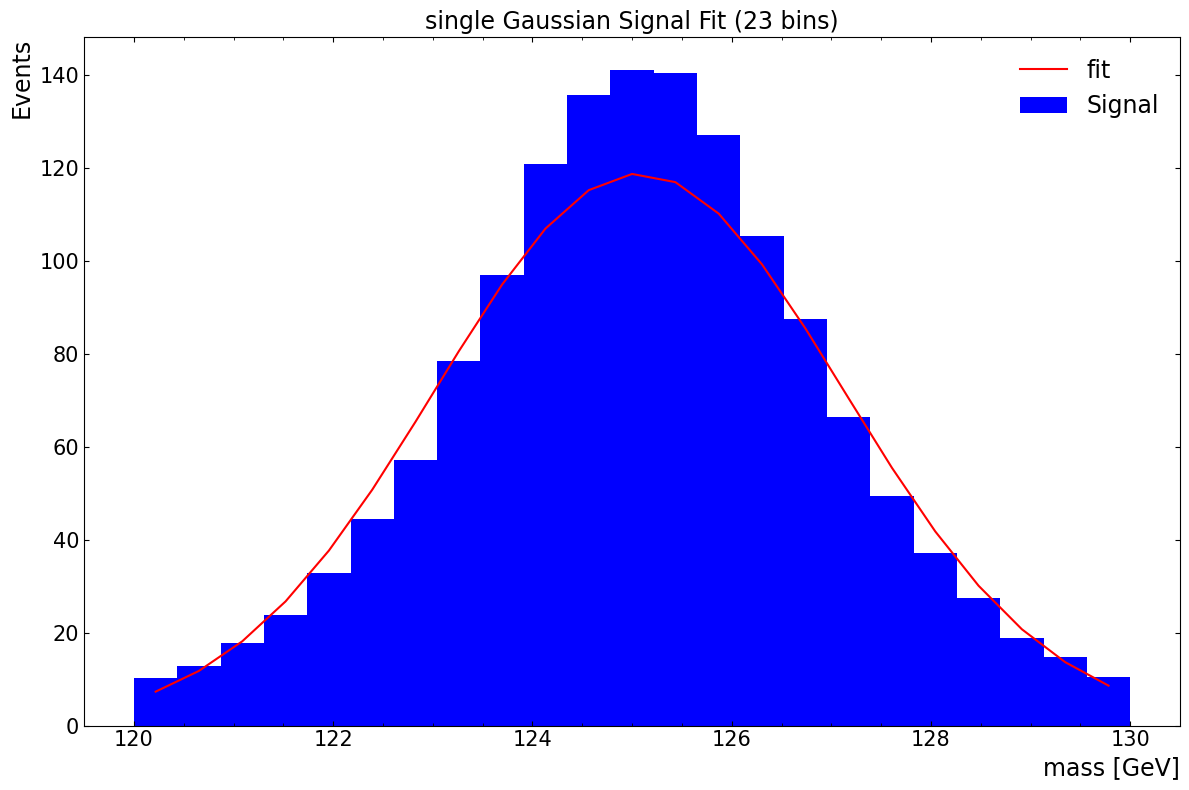

Elapsed time = 0.0s


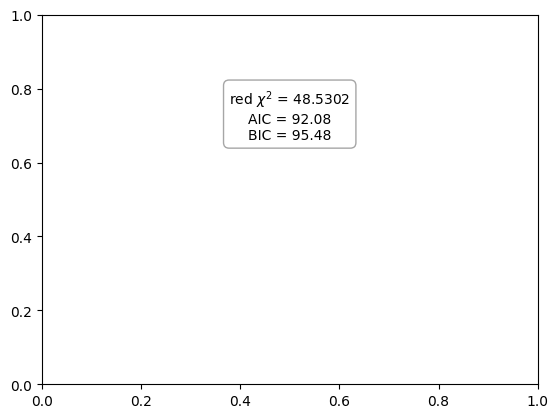

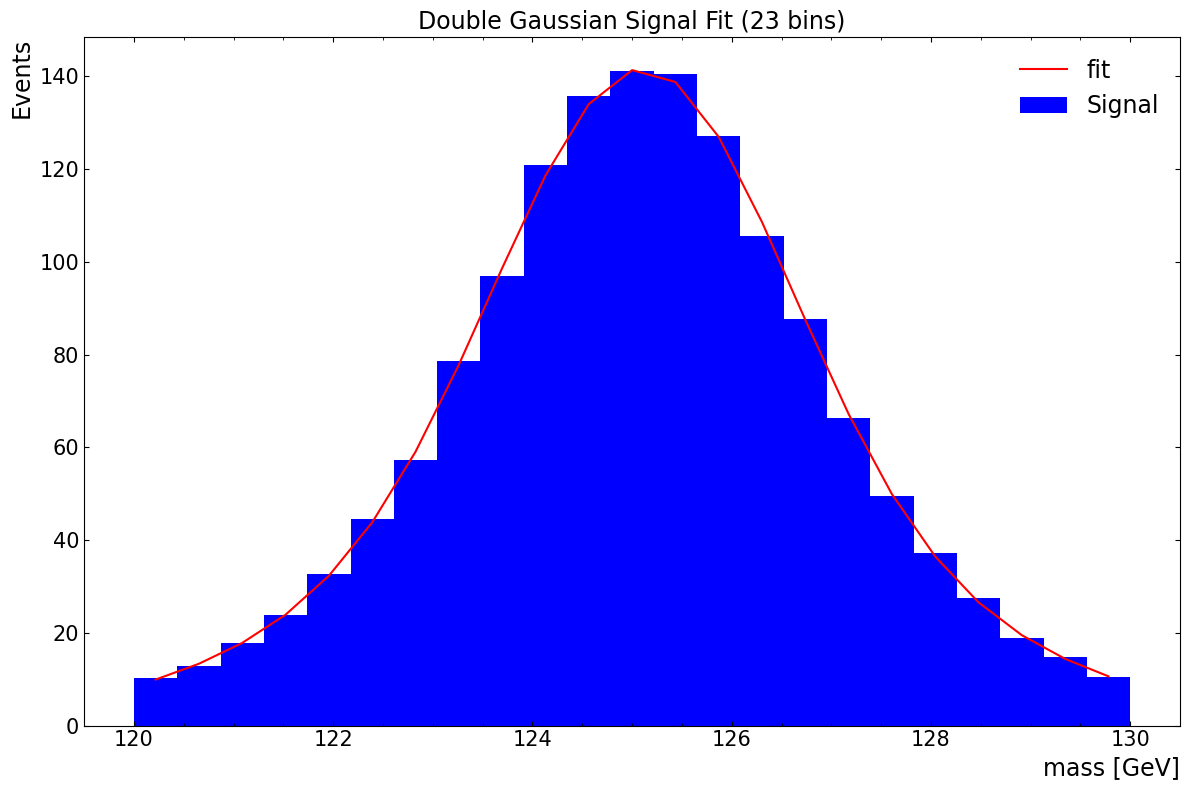

Elapsed time = 0.0s


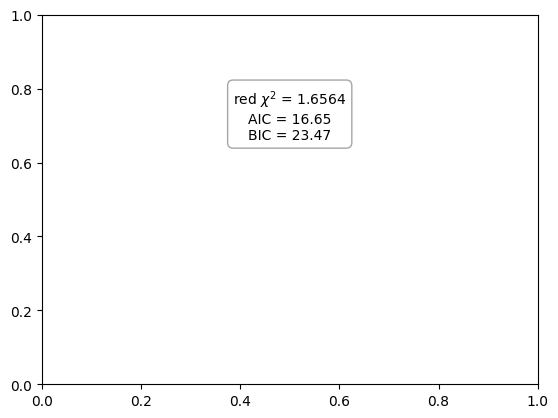

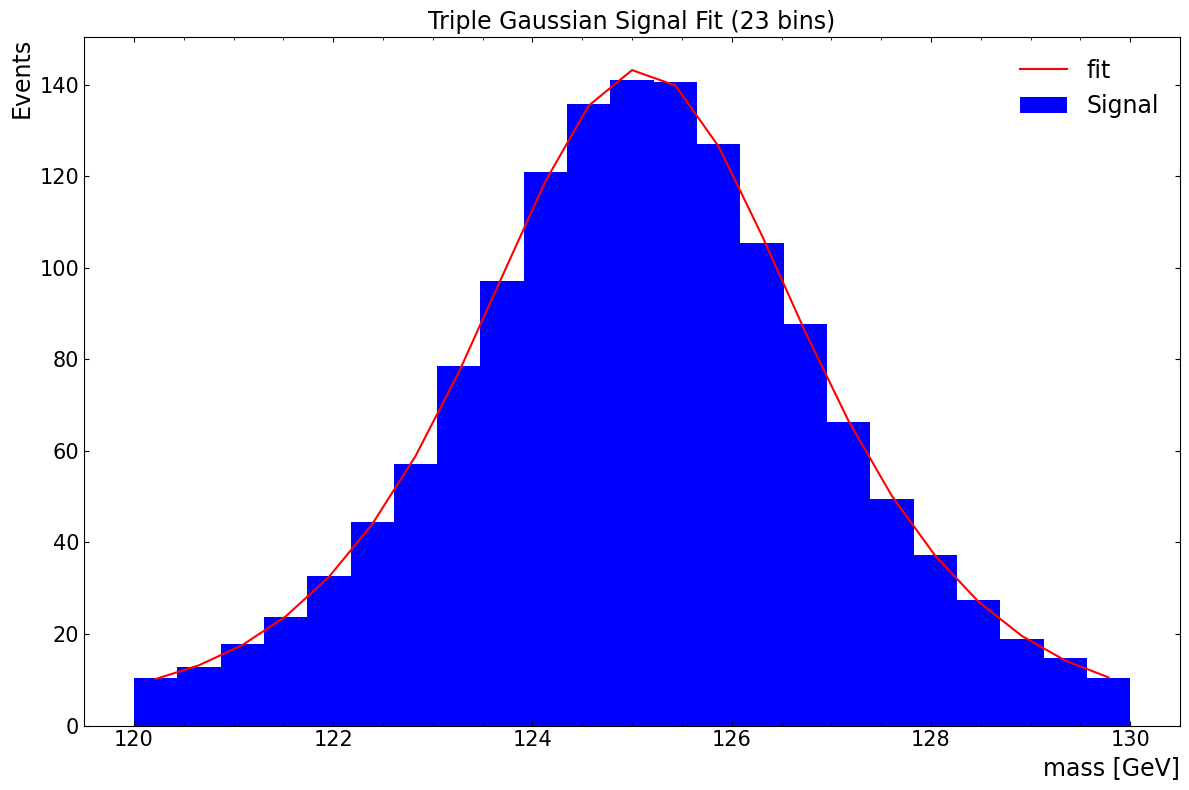

/tmp/ipykernel_2420/2939913295.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


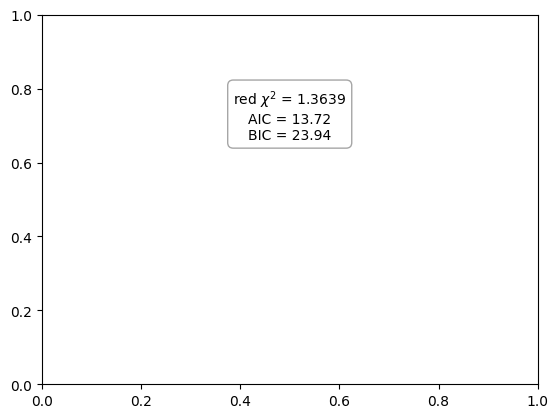

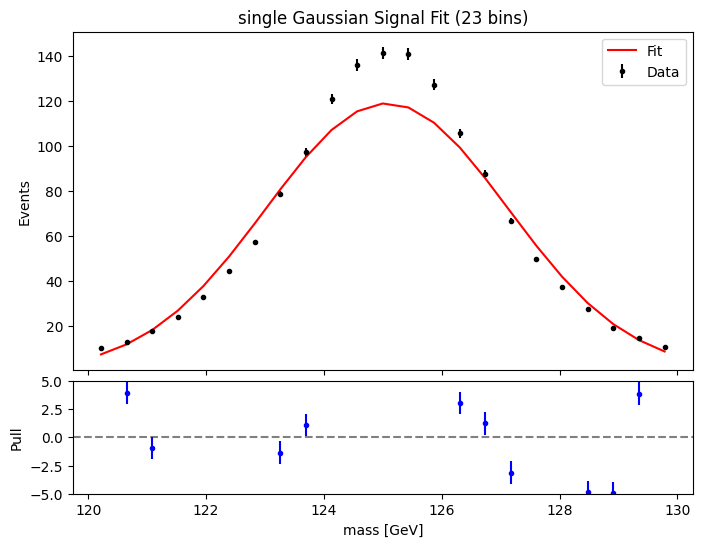

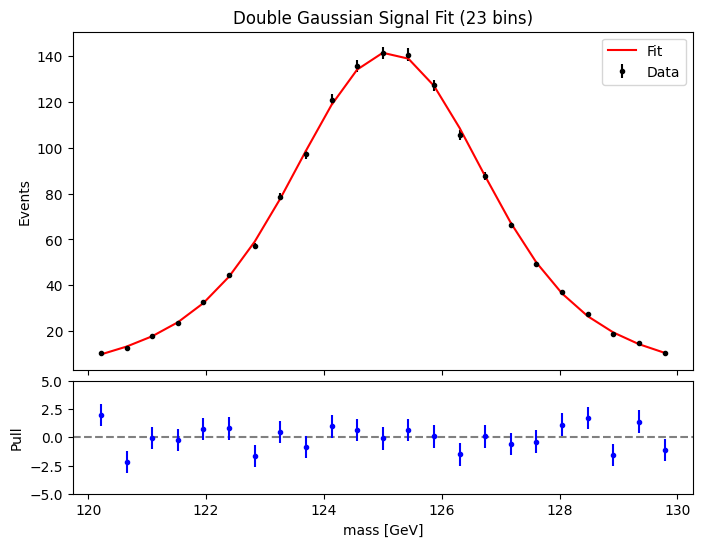

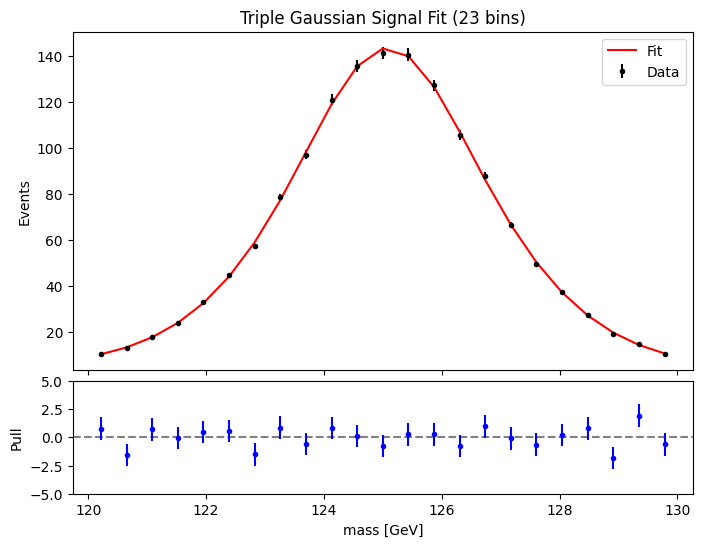

In [18]:
def plot_fit_with_residuals(bin_centres, data_y, data_y_err, fit_result, title, x_label='mass [GeV]'):
    best_fit_y = fit_result.best_fit
    residuals = data_y - best_fit_y
    pulls = residuals / data_y_err

    fig, (ax_main, ax_resid) = plt.subplots(
        2, 1, figsize=(8, 6), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
    )

    # --- Main plot ---
    ax_main.errorbar(bin_centres, data_y, yerr=data_y_err, fmt='o', color='black', label='Data', markersize=3)
    ax_main.plot(bin_centres, best_fit_y, color='red', label='Fit')
    ax_main.set_ylabel('Events')
    ax_main.set_title(title)
    ax_main.legend()

    # --- Residuals plot ---
    ax_resid.axhline(0, color='gray', linestyle='--')
    ax_resid.errorbar(bin_centres, pulls, yerr=np.ones_like(data_y_err), fmt='o', color='blue', markersize=3)
    ax_resid.set_ylabel('Pull')
    ax_resid.set_xlabel(x_label)
    ax_resid.set_ylim(-5, 5)

    plt.tight_layout()
    return fig

# ==========================================================
# MODEL 1: SINGLE GAUSSIAN
# ==========================================================
gaussian_model = GaussianModel(prefix='g1_')
gaussian_params = gaussian_model.guess(
    signal_x,
    x=bin_centres
)

gauss_fit = gaussian_model.fit(
    signal_x,
    gaussian_params,
    x=bin_centres,
    weights=1/signal_x_err,
    nan_policy='omit'
)

print("\n" + "="*15 + " SINGLE GAUSSIAN FIT RESULTS " + "="*15)
print(fit_report(gauss_fit))

# ==========================================================
# MODEL 2: DOUBLE GAUSSIAN (Core + Tail)
# ==========================================================
# Create two independent Gaussian models
g1 = GaussianModel(prefix='g1_')
g2 = GaussianModel(prefix='g2_')

# Combine them
double_gauss_model = g1 + g2

# Use guess for each Gaussian separately
params = g1.guess(signal_x, x=bin_centres) + g2.guess(signal_x, x=bin_centres)

# Optional: set bounds to keep parameters physically meaningful
params['g1_sigma'].set(min=0.5, max=5)
params['g2_sigma'].set(min=0.5, max=5)
params['g1_center'].set(min=124, max=126)
params['g2_center'].set(min=124, max=126)
params['g1_amplitude'].set(min=0)
params['g2_amplitude'].set(min=0)

# Fit the double Gaussian
double_gauss_fit = double_gauss_model.fit(
    signal_x,
    params,
    x=bin_centres,
    weights=1/signal_x_err,
    nan_policy='omit'
)

print("\n" + "="*15 + " DOUBLE GAUSSIAN FIT RESULTS " + "="*15)
print(fit_report(double_gauss_fit))

# ==========================================================
# MODEL 3: TRIPLE GAUSSIAN (Core + Tail + Extra Tail)
# ==========================================================
# Create three independent Gaussian models
g1 = GaussianModel(prefix='g1_')
g2 = GaussianModel(prefix='g2_')
g3 = GaussianModel(prefix='g3_')  # New third Gaussian

# Combine them into one model
triple_gauss_model = g1 + g2 + g3

# Use guess for each Gaussian separately
params = g1.guess(signal_x, x=bin_centres) + g2.guess(signal_x, x=bin_centres) + g3.guess(signal_x, x=bin_centres)

# Optional: set bounds to keep parameters physically meaningful
params['g1_sigma'].set(min=0.5, max=5)
params['g2_sigma'].set(min=0.5, max=5)
params['g3_sigma'].set(min=0.5, max=5)  # Set bounds for the third Gaussian

params['g1_center'].set(min=124, max=126)
params['g2_center'].set(min=124, max=126)
params['g3_center'].set(min=122, max=128)  # Set center bounds for the third Gaussian

params['g1_amplitude'].set(min=0)
params['g2_amplitude'].set(min=0)
params['g3_amplitude'].set(min=0)  # Amplitude for the third Gaussian

# Fit the triple Gaussian
triple_gauss_fit = triple_gauss_model.fit(
    signal_x,
    params,
    x=bin_centres,
    weights=1/signal_x_err,
    nan_policy='omit'
)

# Print the fit results for the triple Gaussian model
print("\n" + "="*15 + " TRIPLE GAUSSIAN FIT RESULTS " + "="*15)
print(fit_report(triple_gauss_fit))

# ==========================================================
# PRINT COMPARISON SUMMARY
# ==========================================================
fits = {
    'Gaussian': gauss_fit,
    'DoubleGauss': double_gauss_fit,
    'TripleGauss': triple_gauss_fit,  # Add Triple Gaussian fit to the comparison
}

print(f"\n{'='*10} SIGNAL MODEL COMPARISON SUMMARY ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)}) {'='*10}")
for name, result in fits.items():
    print(f"{name:12s}  χ²={result.chisqr:10.3f}  redχ²={result.redchi:8.4f}  "
          f"AIC={result.aic:10.3f}  BIC={result.bic:10.3f}  R²={result.rsquared:8.4f}")

# ==========================================================
# PLOT EACH SIGNAL FIT
# ==========================================================

def annotate_fit_stats(ax, fit_result):
    """Annotate reduced χ², AIC, and BIC inside the given axis (centered)."""
    stats_text = (
        f"red $\\chi^2$ = {fit_result.redchi:.4f}\n"
        f"AIC = {fit_result.aic:.2f}\n"
        f"BIC = {fit_result.bic:.2f}"
    )
    ax.text(
        0.5, 0.8, stats_text,  # <— 0.8 moves it near top center (better for readability)
        transform=ax.transAxes,
        fontsize=10,
        va='top', ha='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.4')
    )

plot_dict = {'Signal': data['Hyy_1 x1']}
color_list = ['b']  # blue (signal)

fit_titles = {
    'Gaussian': f'single Gaussian Signal Fit ({int(num_bins)} bins)',
    'DoubleGauss': f'Double Gaussian Signal Fit ({int(num_bins)} bins)',
    'TripleGauss': f'Triple Gaussian Signal Fit ({int(num_bins)} bins)',  # Title for Triple Gaussian
}

# 1. Gaussian
fig, hist = plot_stacked_hist(
    plot_dict, plot_variable, color_list,
    num_bins, xmin, xmax, x_label,
    fit=gauss_fit.best_fit, marker='.',
    title=fit_titles['Gaussian']
)
annotate_fit_stats(plt.gca(), gauss_fit)

# 2. Double Gaussian
fig, hist = plot_stacked_hist(
    plot_dict, plot_variable, color_list,
    num_bins, xmin, xmax, x_label,
    fit=double_gauss_fit.best_fit, marker='.',
    title=fit_titles['DoubleGauss']
)
annotate_fit_stats(plt.gca(), double_gauss_fit)

# 3. Triple Gaussian
fig, hist = plot_stacked_hist(
    plot_dict, plot_variable, color_list,
    num_bins, xmin, xmax, x_label,
    fit=triple_gauss_fit.best_fit, marker='.',
    title=fit_titles['TripleGauss']
)
annotate_fit_stats(plt.gca(), triple_gauss_fit)

# Residual plots
plot_fit_with_residuals(bin_centres, signal_x, signal_x_err, gauss_fit, fit_titles['Gaussian'])
plot_fit_with_residuals(bin_centres, signal_x, signal_x_err, double_gauss_fit, fit_titles['DoubleGauss'])
plot_fit_with_residuals(bin_centres, signal_x, signal_x_err, triple_gauss_fit, fit_titles['TripleGauss'])

plt.show()



=============== COMBINED TRIPLE GAUSSIAN + POLYNOMIAL7 FIT RESULTS ===============
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 346
    # variables        = 9
    chi-square         = 388.180223
    reduced chi-square = 1.15187010
    Akaike info crit   = 57.8007080
    Bayesian info crit = 92.4186570
    R-squared          = 0.99952853
[[Variables]]
    c0:            121023.926 +/- 39690.9994 (32.80%) (init = 124003.4)
    c1:           -2789.21368 +/- 1626.54388 (58.32%) (init = -2908.899)
    c2:            27.5850980 +/- 28.0341391 (101.63%) (init = 29.60064)
    c3:           -0.14156778 +/- 0.26361991 (186.21%) (init = -0.160044)
    c4:            3.4989e-04 +/- 0.00146188 (417.81%) (init = 0.0004496185)
    c5:           -1.3073e-07 +/- 4.7847e-06 (3660.03%) (init = -4.481551e-07)
    c6:           -1.1307e-09 +/- 8.5658e-09 (757.60%) (init = -5.782613e-10)
    c7:            1.6641e-12 +/- 6.4761e-12 (389.17%) (init

/tmp/ipykernel_2420/2939913295.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


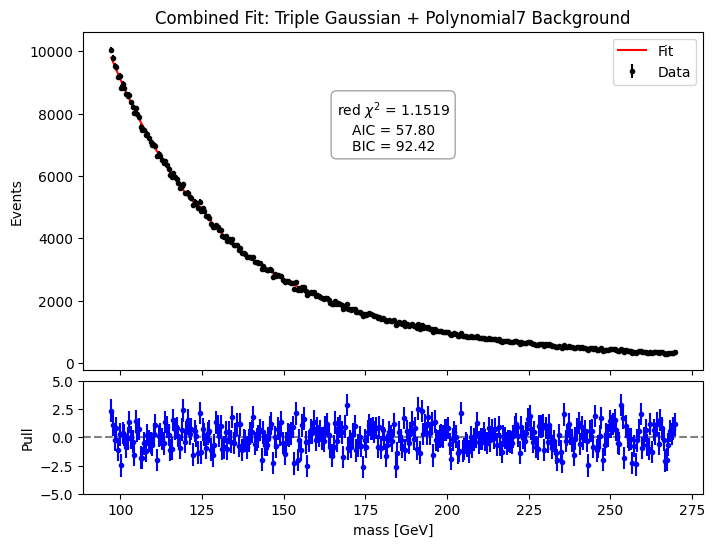


=============== COMBINED TRIPLE GAUSSIAN + EXPONENTIAL2 FIT RESULTS ===============
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 11
    # data points      = 346
    # variables        = 4
    chi-square         = 405.049804
    reduced chi-square = 1.18435615
    Akaike info crit   = 62.5196552
    Bayesian info crit = 77.9054103
    R-squared          = 0.99950786
[[Variables]]
    a0:            12.1087974 +/- 0.01717469 (0.14%) (init = 12.10797)
    a1:           -0.03374818 +/- 2.2283e-04 (0.66%) (init = -0.0337348)
    a2:            3.7858e-05 +/- 6.7544e-07 (1.78%) (init = 3.781522e-05)
    g1_amplitude:  84.3495944 +/- 24.9911242 (29.63%) (init = 0)
    g1_center:     125.0706 (fixed)
    g1_sigma:      1.080711 (fixed)
    g1_fwhm:       2.544881 (fixed)
    g1_height:     39.93854 (fixed)
    g2_amplitude:  343.232670 +/- 101.693083 (29.63%) == '4.069168 * g1_amplitude'
    g2_center:     125.1158 (fixed)
    g2_sigma:      1.885327 (fixed)
  

/tmp/ipykernel_2420/2939913295.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


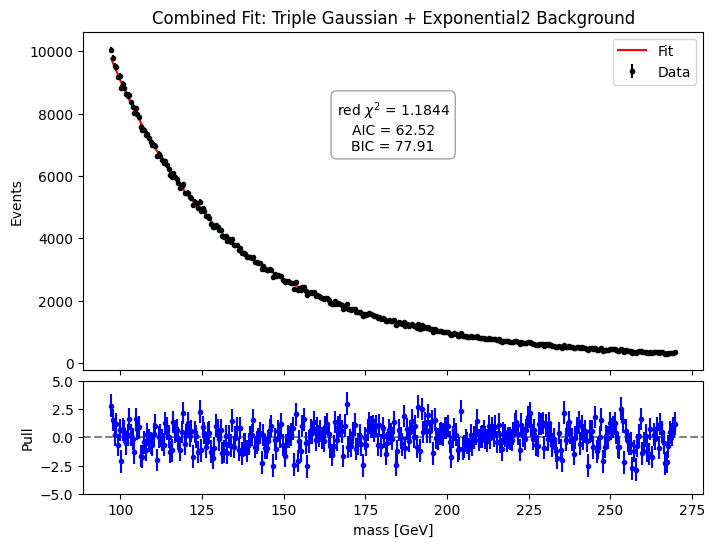


=============== COMBINED TRIPLE GAUSSIAN + LAURENT7 FIT RESULTS ===============
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 28
    # data points      = 346
    # variables        = 8
    chi-square         = 385.353598
    reduced chi-square = 1.14009940
    Akaike info crit   = 53.2720103
    Bayesian info crit = 84.0435205
    R-squared          = 0.99955539
[[Variables]]
    A:             2157316.37 +/- 1319402.94 (61.16%) (init = 2201579)
    B:            -2.1714e+09 +/- 1.3062e+09 (60.16%) (init = -2.220915e+09)
    C:             8.8713e+11 +/- 5.2692e+11 (59.40%) (init = 9.096044e+11)
    D:            -1.8696e+14 +/- 1.1087e+14 (59.30%) (init = -1.922365e+14)
    E:             2.2142e+16 +/- 1.2835e+16 (57.97%) (init = 2.281597e+16)
    F:            -1.3741e+18 +/- 7.7564e+17 (56.45%) (init = -1.418592e+18)
    G:             3.4711e+19 +/- 1.9128e+19 (55.11%) (init = 3.589372e+19)
    g1_amplitude:  90.3190200 +/- 28.1309346 (31.15%) (init

/tmp/ipykernel_2420/2939913295.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


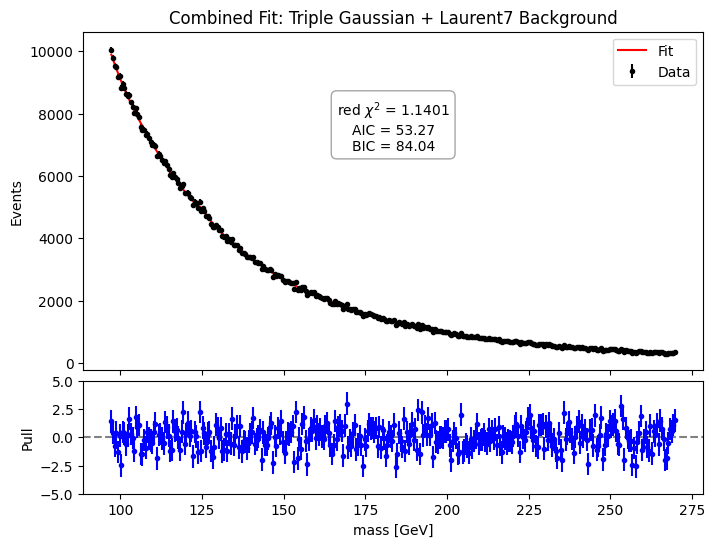


=============== COMBINED TRIPLE GAUSSIAN + RATIONAL22 FIT RESULTS ===============
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 44
    # data points      = 346
    # variables        = 6
    chi-square         = 403.279171
    reduced chi-square = 1.18611521
    Akaike info crit   = 65.0038367
    Bayesian info crit = 88.0824693
    R-squared          = 0.99951205
[[Variables]]
    a0:           -1.7993e+13 +/- 6.1583e+20 (3422625004.52%) (init = -1.835394e+10)
    a1:            1.0398e+11 +/- 3.5591e+18 (3422687575.32%) (init = 1.059069e+08)
    a2:           -1.7139e+08 +/- 5.8664e+15 (3422746269.79%) (init = -174307.6)
    b1:            451634.809 +/- 1.5445e+13 (3419867984.48%) (init = 491.4928)
    b2:           -106277.658 +/- 3.6373e+12 (3422434961.61%) (init = -108.8555)
    g1_amplitude:  135.345858 +/- 25.7663751 (19.04%) (init = 0)
    g1_center:     125.0706 (fixed)
    g1_sigma:      1.080711 (fixed)
    g1_fwhm:       2.544881 (fixed)
   

/tmp/ipykernel_2420/2939913295.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


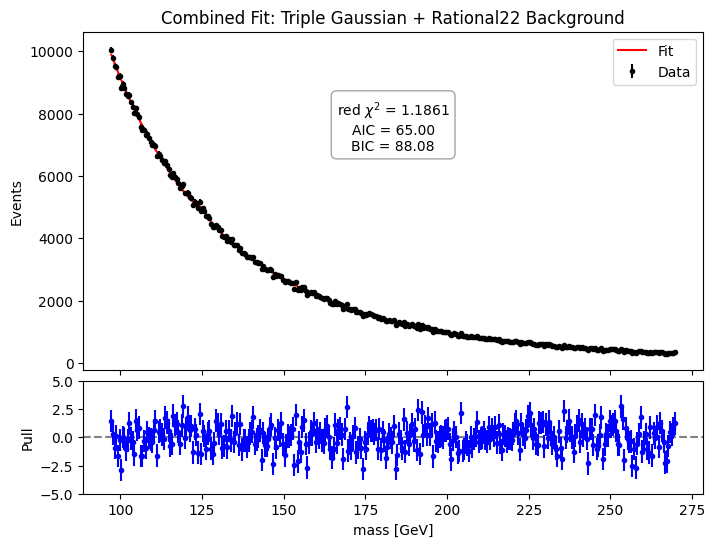


=============== COMBINED TRIPLE GAUSSIAN + DIJET4 FIT RESULTS ===============
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 3183
    # data points      = 346
    # variables        = 5
    chi-square         = 390.071200
    reduced chi-square = 1.14390381
    Akaike info crit   = 51.4821173
    Bayesian info crit = 70.7143112
    R-squared          = 0.99953199
[[Variables]]
    p0:            1.2278e-16 +/- 7.5974e-16 (618.76%) (init = 1.858903e-15)
    p1:           -84.4296795 +/- 32.7609914 (38.80%) (init = -70.04862)
    p2:            15.2043303 +/- 2.20940071 (14.53%) (init = 14.23361)
    p3:            1.22005761 +/- 0.20393025 (16.71%) (init = 1.130624)
    g1_amplitude:  109.472691 +/- 25.9915000 (23.74%) (init = 0)
    g1_center:     125.0706 (fixed)
    g1_sigma:      1.080711 (fixed)
    g1_fwhm:       2.544881 (fixed)
    g1_height:     39.93854 (fixed)
    g2_amplitude:  445.462769 +/- 105.763781 (23.74%) == '4.069168 * g1_amplitude'
   

/tmp/ipykernel_2420/2939913295.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


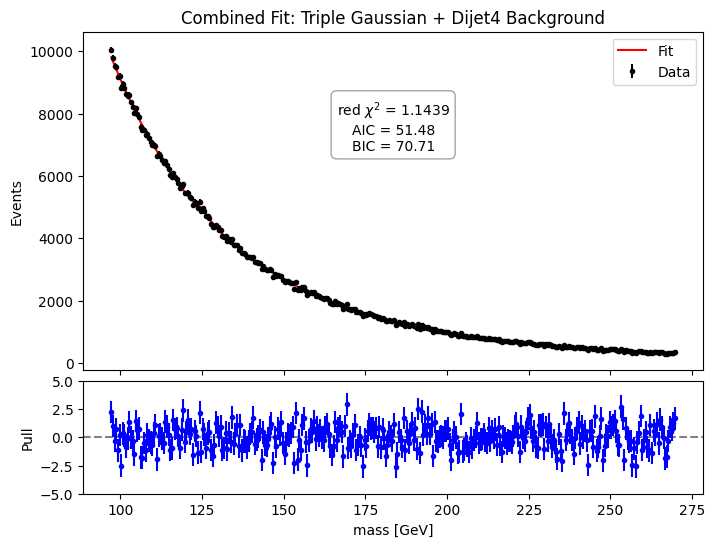

Elapsed time = 0.1s


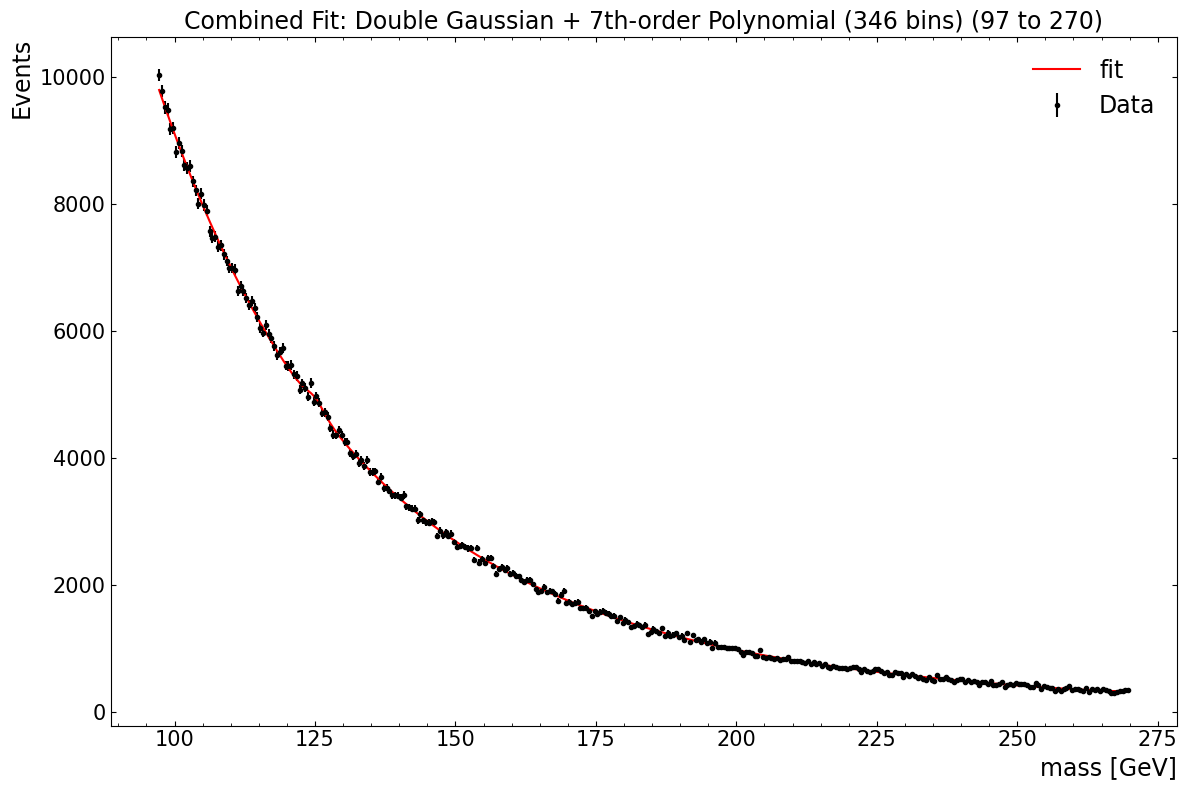

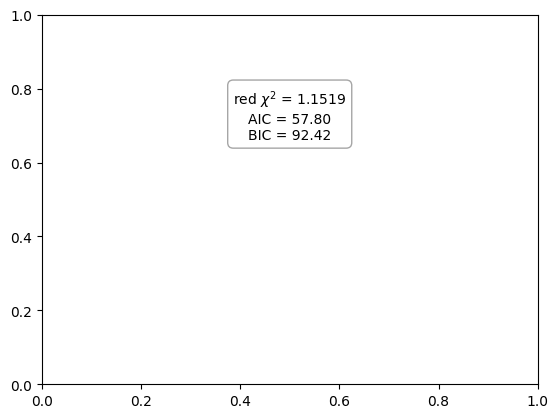

Elapsed time = 0.1s


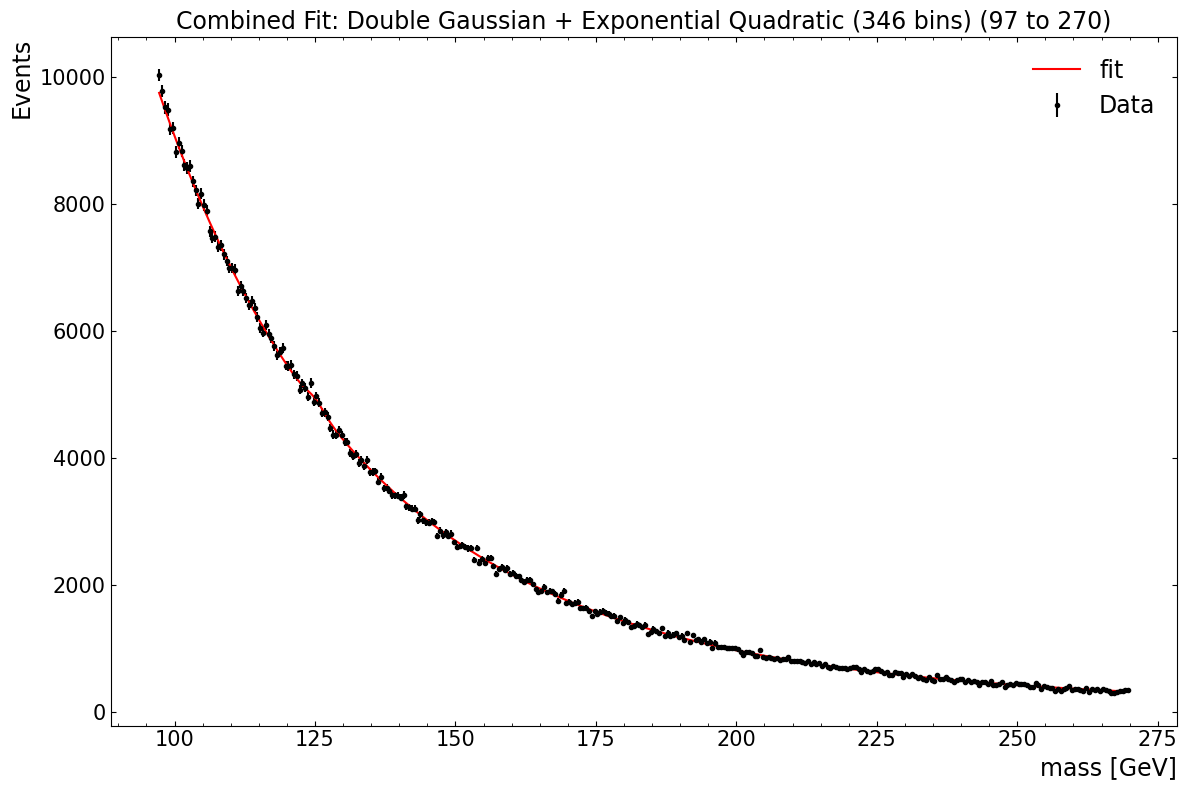

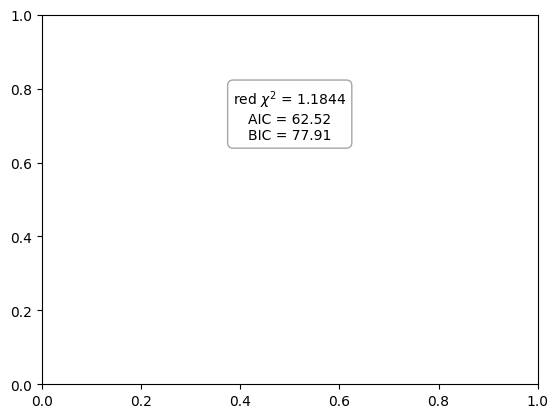

Elapsed time = 0.4s


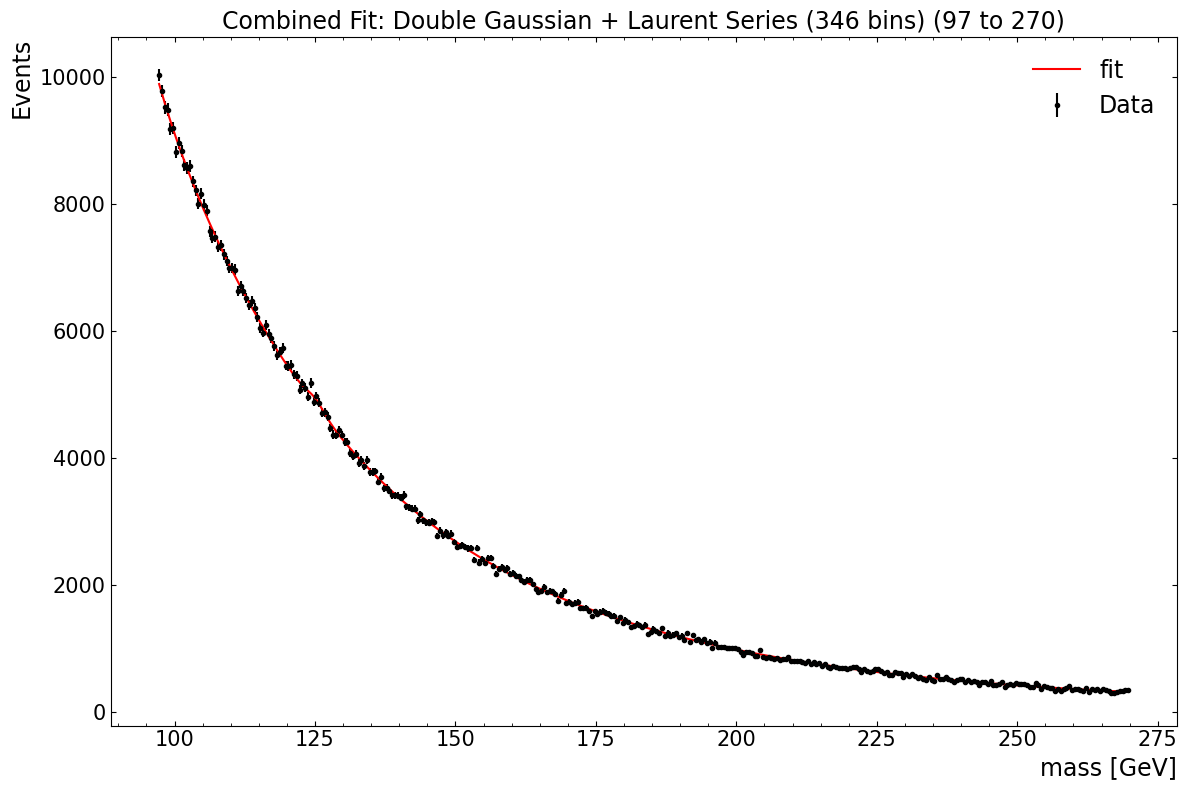

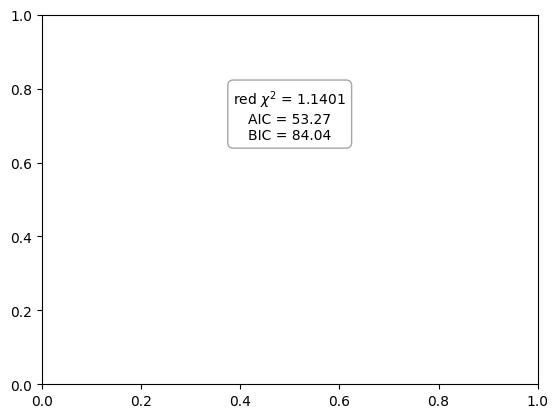

Elapsed time = 0.1s


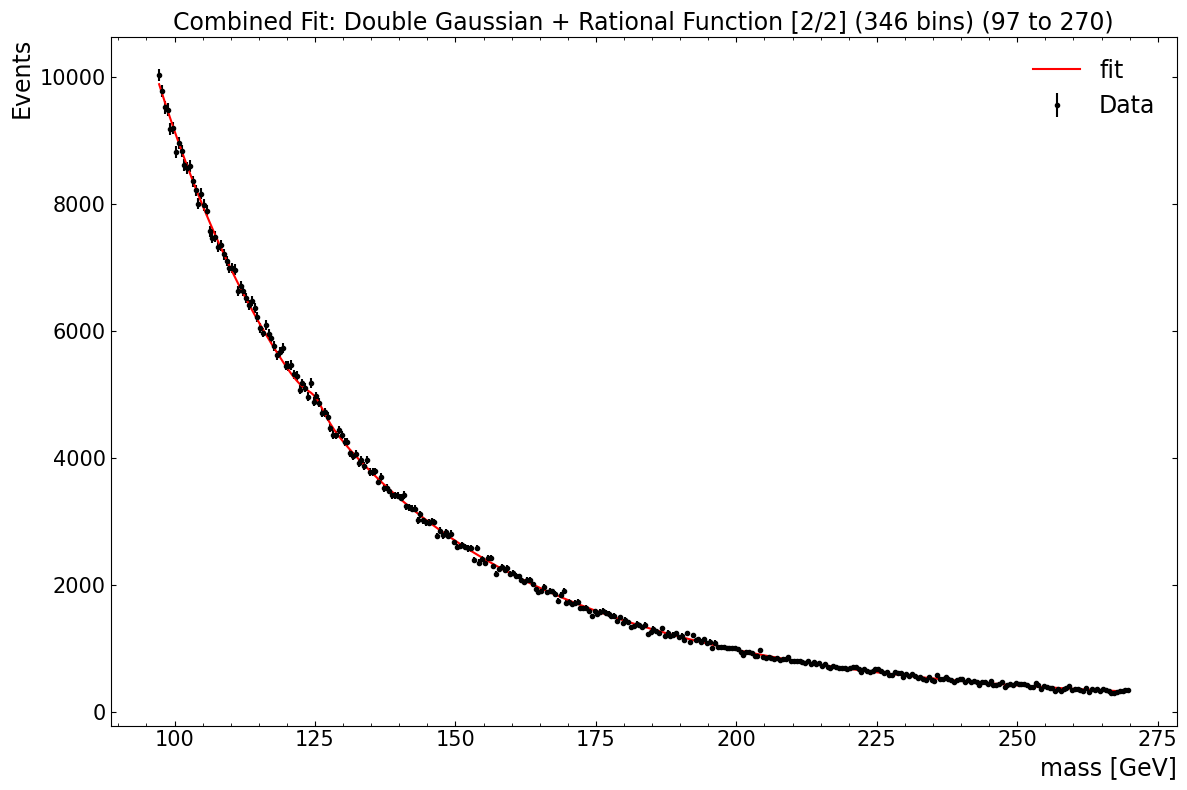

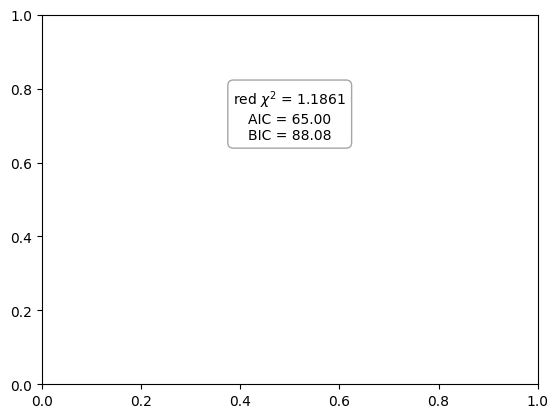

Elapsed time = 0.1s


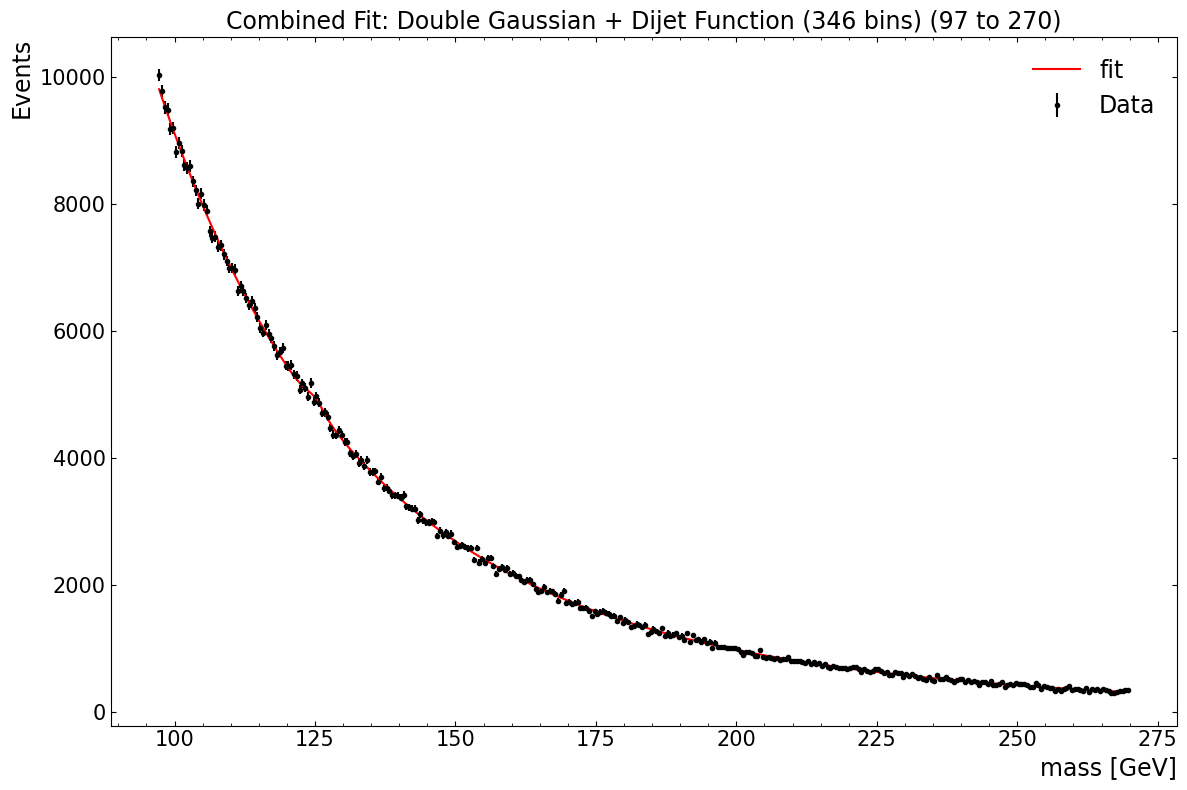

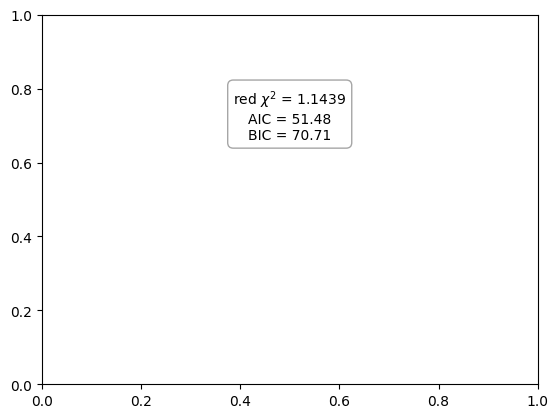

In [19]:
# ------------------------
# 5. Prepare data histogram
# ------------------------
xmin, xmax = 97,270
num_bins = 2 * (xmax - xmin)
bin_width_signal = (130 - 120) / 23
bin_width_combined = (xmax - xmin) / num_bins

data_x = data['GamGam_1 x1']['mass']
data_weight = np.ones_like(data_x)

bin_edges = np.linspace(xmin, xmax, num_bins + 1)
data_hist, _ = np.histogram(data_x, bins=bin_edges, weights=data_weight)
data_hist = np.array(data_hist, dtype=float)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
data_err = np.sqrt(data_hist)
data_err[data_err == 0] = 1.0  # avoid divide-by-zero

x_label = 'mass [GeV]'

# ------------------------
# Prepare triple Gaussian signal model with fitted params
# ------------------------
g1 = GaussianModel(prefix='g1_')
g2 = GaussianModel(prefix='g2_')
g3 = GaussianModel(prefix='g3_')
double_gauss_model = g1 + g2 + g3
fit_vals = triple_gauss_fit.params.valuesdict()
triple_gauss_params = triple_gauss_model.make_params(**triple_gauss_fit.params.valuesdict())
R2 = fit_vals['g2_amplitude'] / fit_vals['g1_amplitude']
R3 = fit_vals['g3_amplitude'] / fit_vals['g1_amplitude']
triple_gauss_params['g1_center'].set(value=fit_vals['g1_center'], vary=False)
triple_gauss_params['g2_center'].set(value=fit_vals['g2_center'], vary=False)
triple_gauss_params['g3_center'].set(value=fit_vals['g3_center'], vary=False)
triple_gauss_params['g1_sigma'].set(value=fit_vals['g1_sigma'], vary=False)
triple_gauss_params['g2_sigma'].set(value=fit_vals['g2_sigma'], vary=False)
triple_gauss_params['g3_sigma'].set(value=fit_vals['g3_sigma'], vary=False)
triple_gauss_params['g1_amplitude'].set(value=0, vary=True)
triple_gauss_params['g2_amplitude'].expr = f"{R2:.6f} * g1_amplitude"
triple_gauss_params['g3_amplitude'].expr = f"{R3:.6f} * g1_amplitude"

# ------------------------
# Annotation function
# ------------------------
def annotate_fit_stats(ax, fit_result):
    stats_text = (
        f"red $\\chi^2$ = {fit_result.redchi:.4f}\n"
        f"AIC = {fit_result.aic:.2f}\n"
        f"BIC = {fit_result.bic:.2f}"
    )
    ax.text(
        0.5, 0.8, stats_text,
        transform=ax.transAxes,
        fontsize=10,
        va='top', ha='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.4')
    )

# ------------------------
# Background models dictionary 
# ------------------------
background_models = {
    'Polynomial7': (poly_model, poly_fit.params),
    'Exponential2': (exp_model, exp_fit.params),
    'Laurent7': (laur_model, laur_fit.params),
    'Rational22': (rational_model, rational_fit.params), 
    'Dijet4': (dijet_model, dijet_fit.params),
}

# ------------------------
# Combined fit function
# ------------------------
def combine_and_fit(background_model, background_params, model_name):
    combined_model = background_model + triple_gauss_model
    combined_params = background_params + triple_gauss_params

    combined_fit = combined_model.fit(
        data_hist,
        combined_params,
        x=bin_centres,
        weights=1.0 / data_err,
        nan_policy='omit'
    )

    print(f"\n{'='*15} COMBINED TRIPLE GAUSSIAN + {model_name.upper()} FIT RESULTS {'='*15}")
    print(fit_report(combined_fit))

    # Plot combined fit with residuals + pulls
    fig = plot_fit_with_residuals(
        bin_centres, data_hist, data_err, combined_fit,
        title=f'Combined Fit: Triple Gaussian + {model_name} Background',
        x_label=x_label
    )
    annotate_fit_stats(fig.axes[0], combined_fit)  # annotate main plot (top)

    plt.show()

    return combined_fit

# ------------------------
# Run combined fits for all backgrounds
# ------------------------
combined_fits = {}
for name, (bkg_model, bkg_params) in background_models.items():
    combined_fits[name] = combine_and_fit(bkg_model, bkg_params, name)
# ------------------------
 # Additional plots: stacked histogram + fit + annotation for all combined fits
# ------------------------
plot_dict = {'Data': data['GamGam_1 x1']}
color_list = ['k']  # black for data
plot_variable = 'mass'

combined_fit_titles = {
    'Polynomial7': f'Combined Fit: Double Gaussian + 7th-order Polynomial ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Exponential2': f'Combined Fit: Double Gaussian + Exponential Quadratic ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Laurent7': f'Combined Fit: Double Gaussian + Laurent Series ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Rational22': f'Combined Fit: Double Gaussian + Rational Function [2/2] ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
    'Dijet4': f'Combined Fit: Double Gaussian + Dijet Function ({int(num_bins)} bins) ({int(xmin)} to {int(xmax)})',
}

for name, fit_result in combined_fits.items():
    fig, hist = plot_stacked_hist(
        plot_dict,
        plot_variable,
        color_list,
        num_bins, xmin, xmax, x_label,
        fit=fit_result.best_fit,
        marker='.',
        title=combined_fit_titles.get(name, f'Combined Fit: {name}')
    )
    annotate_fit_stats(plt.gca(), fit_result)
    plt.show()

In [21]:
import os
import pandas as pd
import numpy as np

luminosity = 36.6  # fb^-1
save_to_csv = True# True to save to CSV, False to just print

amp_correction = bin_width_signal / bin_width_combined

# --- Compute efficiency ---
produced = produced_event_count('Hyy', luminosity)
efficiency = np.sum(data['Hyy_1 x1']['totalWeight']) / (produced)
print(f"Efficiency = {efficiency:.4e}")

# --- Prepare CSV ---
csv_file = "tightiso_fraction_1.csv"
columns = [
    'Model',
    'cross_section_pb',
    'cross_section_err_pb'
]

# --- Define which models to save ---
# Set True for models you want written to CSV, False otherwise
save_flags = {
    "Polynomial7": True,
    "Exponential2":False,
    "Laurent7": True,
    "Rational22": True,
    "Dijet4": True,
}

# --- Compute cross sections for each combined fit ---
rows_to_append = []

for name, fit_result in combined_fits.items():
    try:
        g1_amp_val = fit_result.params['g1_amplitude'].value
        g1_amp_err = fit_result.params['g1_amplitude'].stderr or 0.0
        g2_amp_val = fit_result.params['g2_amplitude'].value
        g2_amp_err = fit_result.params['g2_amplitude'].stderr or 0.0
        g3_amp_val = fit_result.params['g3_amplitude'].value
        g3_amp_err = fit_result.params['g3_amplitude'].stderr or 0.0

        sigma = (g1_amp_val + g2_amp_val + g3_amp_val) * amp_correction / (efficiency * luminosity)
        sigma_err = (g1_amp_err + g2_amp_err + g3_amp_err) * amp_correction / (efficiency * luminosity)

        print(f"\n{name} Model:")
        print(f"  σ(H→γγ) = {sigma:.3e} ± {sigma_err:.3e} pb")

        # Only append if this model’s save flag is True
        if save_flags.get(name, False):
            rows_to_append.append({
                'Model': name,
                'g1_amplitude': g1_amp_val,
                'g1_amplitude_err': g1_amp_err,
                'cross_section_pb': sigma,
                'cross_section_err_pb': sigma_err
            })
            print(f"  → Marked for CSV export")

    except KeyError:
        print(f"\n{name} Model: g1_amplitude not found in fit parameters.")

# --- Append to CSV only if save_to_csv is True ---
if save_to_csv and rows_to_append:
    df_new = pd.DataFrame(rows_to_append, columns=columns)
    if os.path.exists(csv_file):
        df_new.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(csv_file, index=False)
    print(f"\n✅ Saved {len(rows_to_append)} selected models to {csv_file}")
else:
    print("\n⚠️ No models saved (either save_to_csv=False or no models marked True).")


The total number of produced events (sum of weights) for Monte Carlo data set Hyy and luminosity 36.6 inverse femtobarns is 4581
Efficiency = 3.3173e-01

Polynomial7 Model:
  σ(H→γγ) = 5.019e+01 ± 1.209e+01 pb
  → Marked for CSV export

Exponential2 Model:
  σ(H→γγ) = 3.789e+01 ± 1.123e+01 pb

Laurent7 Model:
  σ(H→γγ) = 4.057e+01 ± 1.264e+01 pb
  → Marked for CSV export

Rational22 Model:
  σ(H→γγ) = 6.080e+01 ± 1.157e+01 pb
  → Marked for CSV export

Dijet4 Model:
  σ(H→γγ) = 4.917e+01 ± 1.168e+01 pb
  → Marked for CSV export

✅ Saved 4 selected models to tightiso_fraction_1.csv
